In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from scipy.interpolate import splrep, BSpline
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import subplots
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import sklearn
import warnings
warnings.filterwarnings('ignore')

In [2]:
n = 100
p = 1
beta = 3
sigma = 1

In [3]:
x = np.random.normal(size=(n,p))
y = x * beta + np.random.normal(size=(n, 1)) * sigma

colnames = ['x' + str(i) for i in range(1, p+1)]
colnames.insert(0, 'y')

df = pd.DataFrame(np.hstack((y, x)), columns = colnames)

In [4]:
lm = LinearRegression()
lm.fit(x,y)
y_hat = lm.predict(x)
resid = y - y_hat

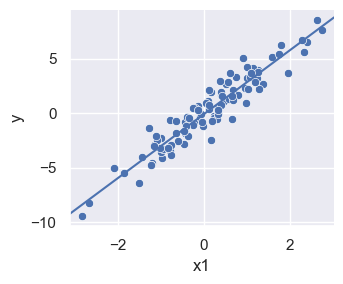

In [8]:
sns.set_theme()
lm_plot = sns.relplot(df, x='x1', y='y', height = 3, aspect = 1.2)
plt.axline((0,lm.intercept_[0]), slope=lm.coef_[0][0])

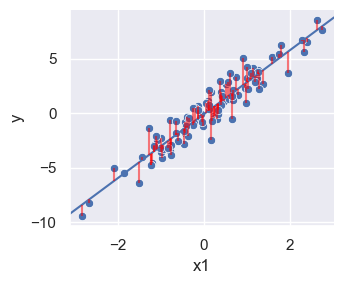

In [11]:
y_min = np.minimum(y, y_hat)
y_max = np.maximum(y, y_hat)
lm_plot = sns.relplot(df, x='x1', y='y', height = 3, aspect = 1.2)
plt.axline((0, lm.intercept_[0]), slope=lm.coef_[0][0])
lm_plot.ax.vlines(x=list(x[:,0]), ymin=list(y_min[:,0]), ymax=list(y_max[:,0]), color = 'red', alpha=0.5)

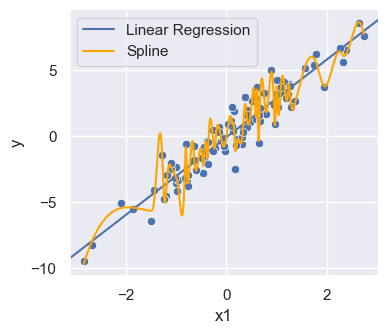

In [12]:
sort_ind = np.argsort(x, axis=0)
xsort = np.take_along_axis(x, sort_ind, axis=0)
ysort = np.take_along_axis(y, sort_ind, axis=0)
tck = splrep(xsort, ysort, s=20)

xspline = np.arange(x.min(), x.max(), 0.01)
yspline = BSpline(*tck)(xspline)

lm_plot = sns.relplot(df, x='x1', y='y', height = 3.5, aspect = 1.2)
plt.axline((0,lm.intercept_[0]), slope=lm.coef_[0][0], label = "Linear Regression")
plt.plot(xspline, yspline,color='orange', label = "Spline")
plt.legend(loc='upper left')

In [13]:
n = 100
p = 90
beta = np.zeros(p)
beta[0]=3
beta[1]=3
cov = 0.6 * np.ones((p, p))
np.fill_diagonal(cov, 1)
x = np.random.multivariate_normal(mean=np.zeros(p), cov=cov, size=n)
y = np.matmul(x, beta) + np.random.normal(size=n)

x_columns = ['x' + str(i+1) for i in range(p)]

In [14]:
# set up cross-validation
K=5
kfold = sklearn.model_selection.KFold(K,random_state=0,shuffle=True)

# function to standardize input
scaler = StandardScaler(with_mean=True, with_std=True)

lassoCV = sklearn.linear_model.ElasticNetCV(n_alphas=100, l1_ratio=1,cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),('lasso', lassoCV)])
pipeCV.fit(x, y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

lambdas, soln_array = sklearn.linear_model.Lasso.path(x, y,l1_ratio=1,n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,columns=x_columns, index=-np.log(lambdas))

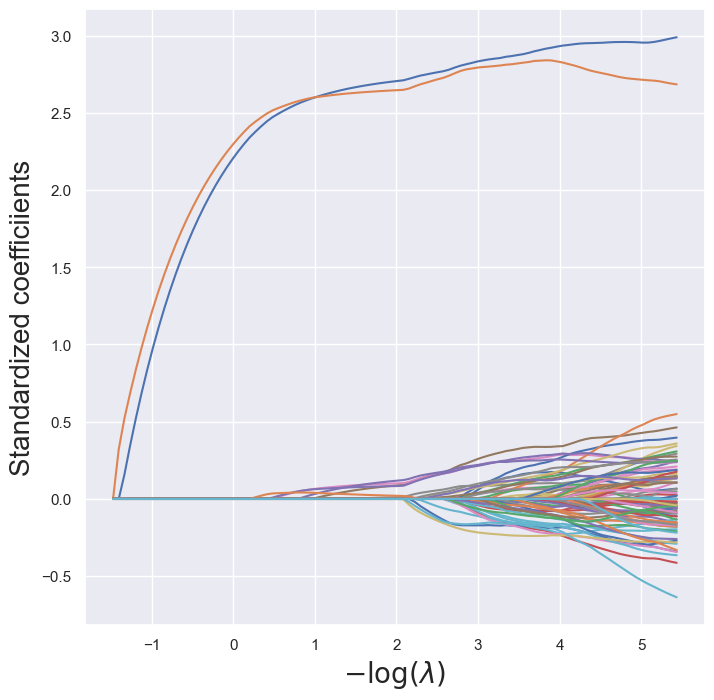

In [15]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficiients', fontsize=20);

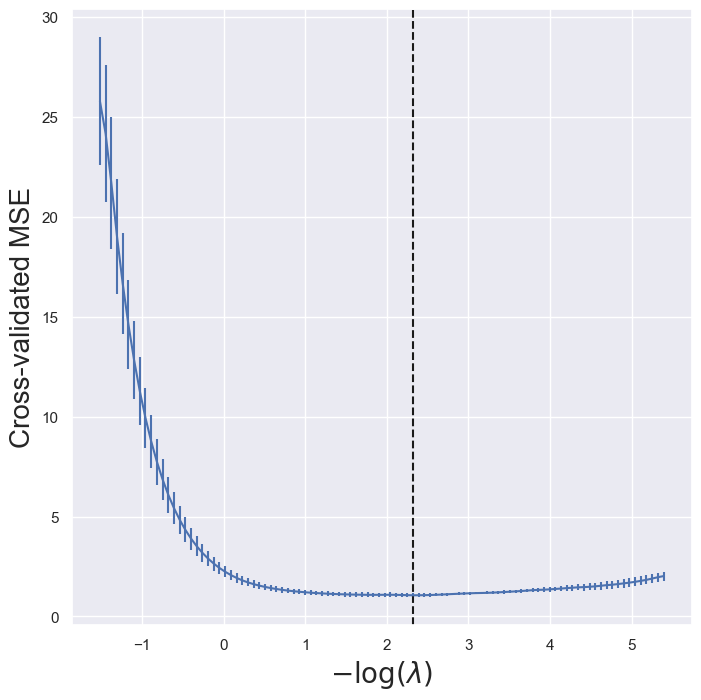

In [16]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),tuned_lasso.mse_path_.mean(1),yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

In [17]:
lambdas = 10**np.linspace(8, -2, 100) / y.std()
ridgeCV = sklearn.linear_model.ElasticNetCV(alphas=lambdas, 
                           l1_ratio=0,
                           cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),
                         ('ridge', ridgeCV)])
pipeCV.fit(x, y)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge',
                 ElasticNetCV(alphas=array([1.96270934e+07, 1.55541358e+07, 1.23263867e+07, 9.76845062e+06,
       7.74133006e+06, 6.13487168e+06, 4.86178089e+06, 3.85287821e+06,
       3.05334009e+06, 2.41971981e+06, 1.91758657e+06, 1.51965456e+06,
       1.20430025e+06, 9.54387352e+05, 7.56335655e+05, 5.99383072e+05,
       4.75000834e+05, 3.76430038e+05,...
       1.62947577e-01, 1.29133168e-01, 1.02335827e-01, 8.10993932e-02,
       6.42698822e-02, 5.09327825e-02, 4.03633591e-02, 3.19872718e-02,
       2.53493659e-02, 2.00889389e-02, 1.59201406e-02, 1.26164391e-02,
       9.99831225e-03, 7.92349147e-03, 6.27923148e-03, 4.97618356e-03,
       3.94354037e-03, 3.12518831e-03, 2.47665829e-03, 1.96270934e-03]),
                              cv=KFold(n_splits=5, random_state=0, shuffle=True),
                              l1_ratio=0))])